<a href="https://colab.research.google.com/github/Bishwa3901/Finance-AI-Quant-Journey/blob/main/Quant_Journey_Day_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
stocks = ["RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS"]

data = yf.download(stocks, start="2018-01-01")['Close']

/tmp/ipykernel_7334/3285366215.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start="2018-01-01")['Close']
[*********************100%***********************]  4 of 4 completed


In [4]:
returns = data.pct_change()
mean_returns = returns.mean()*252
cov_matrix = returns.cov()*252

### Monte Carlo Simulation

In [5]:
num_portfolios = 10000

results = np.zeros((3,num_portfolios))

weights_record = []

In [6]:
for i in range(num_portfolios):

    weights = np.random.random(len(stocks))
    weights /= np.sum(weights)

    weights_record.append(weights)

    portfolio_return = np.sum(weights*mean_returns)

    portfolio_volatility = np.sqrt(
        np.dot(weights.T, np.dot(cov_matrix, weights))
    )

    sharpe = portfolio_return / portfolio_volatility

    results[0,i] = portfolio_return
    results[1,i] = portfolio_volatility
    results[2,i] = sharpe

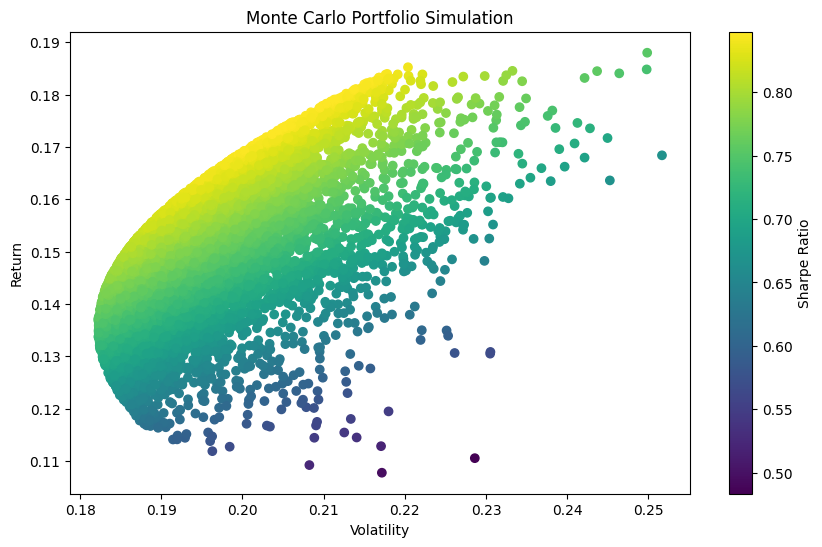

In [7]:
#Visualizing Portfolio Space
plt.figure(figsize=(10,6))

plt.scatter(results[1,:],results[0,:],
            c=results[2,:],
            cmap='viridis')

plt.xlabel("Volatility")
plt.ylabel("Return")
plt.colorbar(label="Sharpe Ratio")

plt.title("Monte Carlo Portfolio Simulation")

plt.show()

In [8]:
#Finding the Best Portfolio
max_sharpe_index = np.argmax(results[2])

best_weights = weights_record[max_sharpe_index]

best_weights

array([0.09023537, 0.39546574, 0.44869449, 0.0656044 ])

In [9]:
print("Best Sharpe Ratio:",results[2,max_sharpe_index])
print("Expected Return:",results[0,max_sharpe_index])
print("Volatility:",results[1,max_sharpe_index])

Best Sharpe Ratio: 0.8476130894133065
Expected Return: 0.17458936622616977
Volatility: 0.20597766646927967
